In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load MNIST dataset

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

11490434/11490434 [==============================] - 5s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


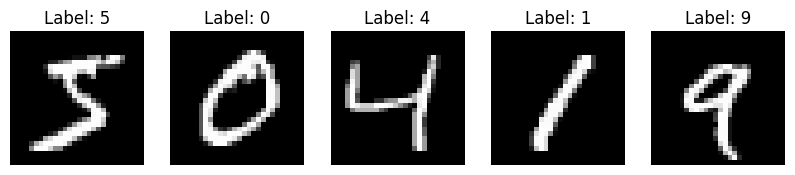

In [3]:
# Display first 5 images

plt.figure(figsize=(10,5))

for i in range(5):
    
    plt.subplot(1,5,i+1)
    
    plt.imshow(x_train[i], cmap='gray')
    
    plt.title("Label: " + str(y_train[i]))
    
    plt.axis('off')

plt.show()

In [4]:
# Reshape data

x_train = x_train.reshape(
    x_train.shape[0],
    28,
    28,
    1
)

x_test = x_test.reshape(
    x_test.shape[0],
    28,
    28,
    1
)

# Normalize pixel values

x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print("Data Normalized Successfully")

Data Normalized Successfully


In [5]:
# Convert labels to categorical format

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("Categorical Labels Created")

Categorical Labels Created


In [6]:
# Create CNN model

model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

print("Model Created Successfully")

Model Created Successfully


In [7]:
# Compile model

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [8]:
# Train model

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=5,
    validation_data=(x_test, y_test)
)

print("Training Completed")

Epoch 1/5
469/469 [==============================] - 34s 68ms/step - loss: 0.3286 - accuracy: 0.9014 - val_loss: 0.0891 - val_accuracy: 0.9735
Epoch 2/5
469/469 [==============================] - 29s 62ms/step - loss: 0.1182 - accuracy: 0.9653 - val_loss: 0.0563 - val_accuracy: 0.9821
Epoch 3/5
469/469 [==============================] - 30s 65ms/step - loss: 0.0862 - accuracy: 0.9742 - val_loss: 0.0491 - val_accuracy: 0.9846
Epoch 4/5
469/469 [==============================] - 31s 67ms/step - loss: 0.0702 - accuracy: 0.9790 - val_loss: 0.0440 - val_accuracy: 0.9855
Epoch 5/5
469/469 [==============================] - 33s 70ms/step - loss: 0.0609 - accuracy: 0.9808 - val_loss: 0.0429 - val_accuracy: 0.9852
Training Completed


In [9]:
# Evaluate model

loss, accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 [==============================] - 3s 8ms/step - loss: 0.0429 - accuracy: 0.9852
Test Loss: 0.04292285069823265
Test Accuracy: 0.9851999878883362


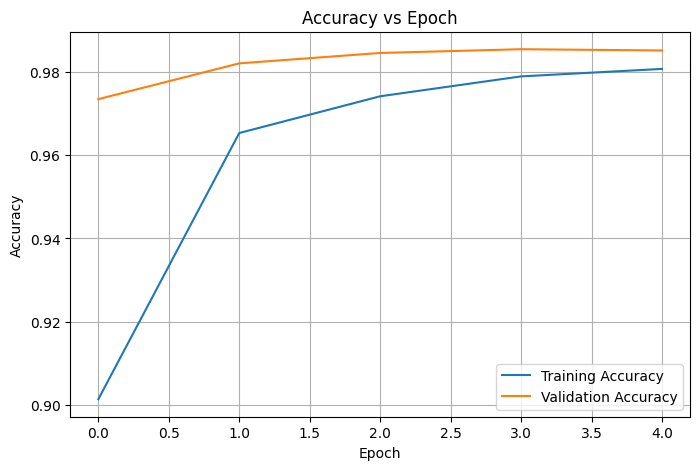

In [10]:
# Plot Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")

plt.legend()

plt.grid(True)

plt.show()

In [11]:
# Predict first test image

prediction = model.predict(x_test[0].reshape(1,28,28,1))

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

1/1 [==============================] - 0s 272ms/step
Predicted Digit: 7


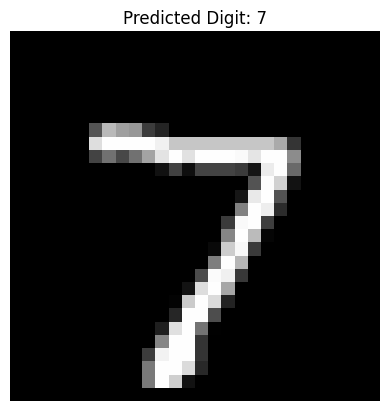

In [12]:
# Display image

plt.imshow(x_test[0].reshape(28,28), cmap='gray')

plt.title("Predicted Digit: " + str(predicted_digit))

plt.axis('off')

plt.show()